# Lukemia - Analiza komórek nowotworowych (CNN)

Przedmiot: Analiza danych multimedialnych

Prowadzący: Łukasz Jeleń

Autorzy: Szymon Drapiński, Maciej Adamski, Dominik Ochej, Jakub Cegłowski

Grupa: SliUM2m G

## Wstęp

Celem projektu jest rozróżnianie zdjęć mikroskopowych białych krwinek pod kątem zmian nowotworowych (białaczki) przy użyciu konwolucyjnej sieci neuronowej (CNN). 
W poprzedniej wersji projektu (plik `main.ipynb`, dane w `data/v1`) klasyfikacja opierała się na ręcznie projektowanych cechach morfologicznych i kolorystycznych. 
W tej wersji wykorzystujemy transfer learning (VGG16) na znacznie większym zbiorze danych pogrupowanym w foldy.

## Opis danych wykorzystywanych w projekcie

Dane znajdują się w katalogu **`/data`** w podziale na trzy foldy: `fold_0`, `fold_1`, `fold_2`. 
Każdy fold zawiera dwa podkatalogi klas:

- **`all`** – komórki wykazujące zmiany nowotworowe (białaczka, klasa pozytywna = 1),
- **`hem`** – komórki zdrowe (klasa negatywna = 0).

### Podział na zbiory

- **Trening:** `data/fold_0/fold_0` (klasy `all` + `hem`)
- **Walidacja:** `data/fold_2/fold_2` (klasy `all` + `hem`)

Fold 1 pozostaje jako rezerwowy zbiór testowy.

## Importy

In [3]:
#pip install -r requirements.txt

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Wczytanie danych

In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
CLASS_NAMES = ["hem", "all"]  # hem=0 (zdrowe), all=1 (białaczka)

TRAIN_DIR = os.path.join("data", "fold_0", "fold_0")
VAL_DIR = os.path.join("data", "fold_2", "fold_2")

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Klasy (w kolejności etykiet):", train_ds.class_names)

Found 3527 files belonging to 2 classes.
Found 3553 files belonging to 2 classes.
Klasy (w kolejności etykiet): ['hem', 'all']


### Preprocessing i prefetch

Dane przepuszczamy przez `preprocess_input` właściwy dla VGG16 (odejmowanie średniej ImageNet) 
oraz korzystamy z `prefetch`, aby GPU/CPU nie czekały na wczytywanie danych.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, training=False):
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=512, seed=42)
    return ds.cache().prefetch(AUTOTUNE)

train_ds_prepared = prepare(train_ds, training=True)
val_ds_prepared = prepare(val_ds, training=False)

## Budowa modelu CNN (transfer learning – VGG16)

In [7]:
base_model = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,845,121 (64.26 MB)

 Trainable params: 2,130,433 (8.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Trening

In [8]:
EPOCHS = 15

history = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS,
)

Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.7102 - loss: 0.9227 - val_accuracy: 0.7692 - val_loss: 0.5545
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.7885 - loss: 0.4814 - val_accuracy: 0.7762 - val_loss: 0.5375
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8287 - loss: 0.4133 - val_accuracy: 0.7768 - val_loss: 0.5562
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.8378 - loss: 0.3862 - val_accuracy: 0.7853 - val_loss: 0.5436
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8489 - loss: 0.3649 - val_accuracy: 0.7864 - val_loss: 0.5381
Epoch 6/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.8514 - loss: 0.3544 - val_accuracy: 0.7878 - val_loss: 0.5374
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8577 - loss: 0.3364 - val_accuracy: 0.7816 - val_loss: 0.5689
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.8662 - loss: 0.3293 - val_accu

## Ocena wyników

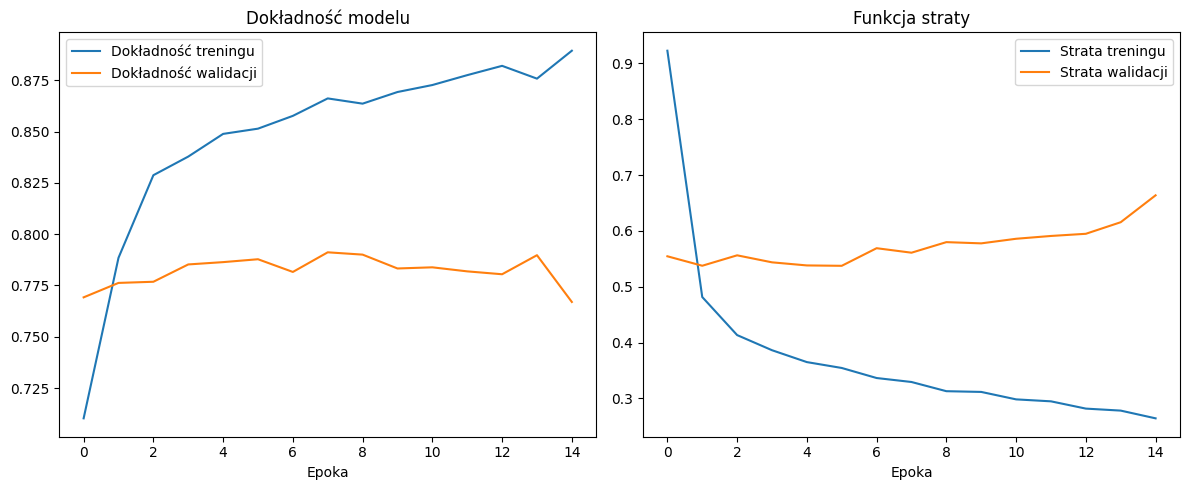

In [9]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Dokładność treningu")
plt.plot(epochs_range, val_acc, label="Dokładność walidacji")
plt.title("Dokładność modelu")
plt.xlabel("Epoka")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Strata treningu")
plt.plot(epochs_range, val_loss, label="Strata walidacji")
plt.title("Funkcja straty")
plt.xlabel("Epoka")
plt.legend()

plt.tight_layout()
plt.show()

112/112 ━━━━━━━━━━━━━━━━━━━━ 58s 518ms/step


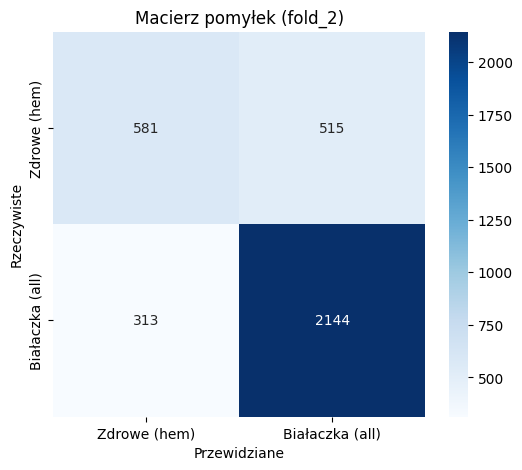

                 precision    recall  f1-score   support

   Zdrowe (hem)       0.65      0.53      0.58      1096
Białaczka (all)       0.81      0.87      0.84      2457

       accuracy                           0.77      3553
      macro avg       0.73      0.70      0.71      3553
   weighted avg       0.76      0.77      0.76      3553



In [10]:
y_pred_prob = model.predict(val_ds_prepared)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = np.concatenate([y.numpy() for _, y in val_ds_prepared], axis=0).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Zdrowe (hem)", "Białaczka (all)"],
    yticklabels=["Zdrowe (hem)", "Białaczka (all)"],
)
plt.xlabel("Przewidziane")
plt.ylabel("Rzeczywiste")
plt.title("Macierz pomyłek (fold_2)")
plt.show()

print(classification_report(y_true, y_pred, target_names=["Zdrowe (hem)", "Białaczka (all)"]))

## Dyskusja wyników

Model VGG16 z transfer learningiem został wytrenowany na foldzie 0 i zwalidowany na foldzie 2. 
Kluczowe metryki do oceny medycznej to **recall klasy `all`** (ile chorych komórek zostało wykrytych) oraz 
macierz pomyłek – szczególnie liczba **false negative** (chore zakwalifikowane jako zdrowe), która w kontekście diagnostyki 
białaczki jest najkosztowniejszym błędem.

## Podsumowanie i wnioski

- Zastosowano transfer learning (VGG16 pre-trenowany na ImageNet) z zamrożoną siecią bazową i nowym klasyfikatorem.
- Zbiór treningowy: `data/fold_0/fold_0`, walidacyjny: `data/fold_2/fold_2` – klasy `all` (białaczka = 1) oraz `hem` (zdrowe = 0).
- W porównaniu do poprzedniej wersji (ręczne cechy na ~114 obrazach z `data/v1`) pracujemy na tysiącach obrazów, co lepiej odpowiada realnym warunkom diagnostycznym.
- Dalsze kroki: fine-tuning górnych warstw VGG16, augmentacja danych, ewaluacja na foldzie 1 jako niezależnym zbiorze testowym.

## Bibliografia

- [Źródło danych](https://www.kaggle.com/datasets/avk256/cnmc-leukemia/data)
- [Dokumentacja TensorFlow / Keras](https://www.tensorflow.org/api_docs)
- [VGG16 – Very Deep Convolutional Networks for Large-Scale Image Recognition](https://arxiv.org/abs/1409.1556)
- [Dokumentacja biblioteki "NumPy"](https://numpy.org/doc/)
- [Dokumentacja biblioteki "matplotlib"](https://matplotlib.org/stable/index.html)
- [Dokumentacja biblioteki "seaborn"](https://seaborn.pydata.org/)
- [Dokumentacja biblioteki "scikit-learn"](https://scikit-learn.org/stable/documentation.html)